INSTALL LIBRARY

In [24]:
!pip install swig
!pip install wrds
!pip install pyportfolioopt
!pip install pandas_market_calendars
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
!pip install --upgrade torch torchvision torchaudio

  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /tmp/pip-req-build-7_ndvujv
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /tmp/pip-req-build-7_ndvujv
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit 69776b349ee4e63efe3826f318aef8e5c5f59648
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /tmp/pip-install-ch_mjd9p/elegantrl_e2c353bec7e34dfd9b4d1c54f274e6c4
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /tmp/pip-install-ch_mjd9p/elegantrl_e2c353bec7e34dfd9b4d1c54f274e6c4
  Resolved https://github.com/AI4Finance-Foundation/ElegantRL.git to commit 5e828af1503098f4da046c0f12432dbd4ef8bd97
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/86

In [12]:
import os
import pandas as pd

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
from finrl import config_tickers
from finrl.main import check_and_make_directories
from finrl.config import INDICATORS, TRAINED_MODEL_DIR, RESULTS_DIR
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl import config_tickers
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl import config_tickers
from finrl.config import INDICATORS
import itertools
check_and_make_directories([TRAINED_MODEL_DIR])

DATE

In [7]:
TRAIN_START_DATE = '2009-01-01'
TRAIN_END_DATE = '2020-07-01'
TRADE_START_DATE = '2020-07-01'
TRADE_END_DATE = '2024-05-01'

SYMBOLS

In [8]:
symbols = [
    'AAPL',
    'MSFT'

]

DOWNLOAD DATA

In [9]:
df_raw = YahooDownloader(start_date = TRAIN_START_DATE,
                                end_date = TRADE_END_DATE,
                                ticker_list = symbols).fetch_data()

YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (7714, 8)


ADD FEATURE

In [10]:
fe = FeatureEngineer(use_technical_indicator=True,
                     tech_indicator_list = INDICATORS,
                     use_vix=True,
                     use_turbulence=True,
                     user_defined_feature = False)

processed = fe.preprocess_data(df_raw)

[*********************100%***********************]  1 of 1 completed

Successfully added technical indicators
Shape of DataFrame:  (3856, 8)


Successfully added vix
Successfully added turbulence index


In [13]:
list_ticker = processed["tic"].unique().tolist()
list_date = list(pd.date_range(processed['date'].min(),processed['date'].max()).astype(str))
combination = list(itertools.product(list_date,list_ticker))

processed_full = pd.DataFrame(combination,columns=["date","tic"]).merge(processed,on=["date","tic"],how="left")
processed_full = processed_full[processed_full['date'].isin(processed['date'])]
processed_full = processed_full.sort_values(['date','tic'])

processed_full = processed_full.fillna(0)

In [14]:
train = data_split(processed_full, TRAIN_START_DATE,TRAIN_END_DATE)
trade = data_split(processed_full, TRADE_START_DATE,TRADE_END_DATE)
print(len(train))
print(len(trade))

5786
1926


In [15]:
stock_dimension = len(train.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 2, State Space: 21


PARAMETER

In [16]:
buy_cost_list = sell_cost_list = [0.001] * stock_dimension
num_stock_shares = [0] * stock_dimension

env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "num_stock_shares": num_stock_shares,
    "buy_cost_pct": buy_cost_list,
    "sell_cost_pct": sell_cost_list,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4
}


e_train_gym = StockTradingEnv(df = train, **env_kwargs)

In [17]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>


In [18]:
agent = DRLAgent(env = env_train)

# Set the corresponding values to 'True' for the algorithms that you want to use
if_using_a2c = True
if_using_ddpg = False
if_using_ppo = True
if_using_td3 = False
if_using_sac = False

In [19]:
model_a2c = agent.get_model("a2c")
model_ppo = agent.get_model('ppo')

if if_using_a2c:
  tmp_path = '/a2c'
  new_logger_a2c = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  model_a2c.set_logger(new_logger_a2c)

if if_using_ppo:
  tmp_path = '/ppo'
  new_logger_ppo = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  model_ppo.set_logger(new_logger_ppo)

{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007}
Using cpu device
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
Using cpu device
Logging to /a2c
Logging to /ppo


TRAIN

In [20]:
trained_ppo = agent.train_model(model=model_ppo,
                             tb_log_name='ppo',
                             total_timesteps=50000) if if_using_ppo else None

-------------------------------------
| time/              |              |
|    fps             | 386          |
|    iterations      | 1            |
|    time_elapsed    | 5            |
|    total_timesteps | 2048         |
| train/             |              |
|    reward          | 0.0024437078 |
-------------------------------------


KeyboardInterrupt: 

In [ ]:
e_trade_gym = StockTradingEnv(df = trade, turbulence_threshold = 50,risk_indicator_col='vix', **env_kwargs)
env_trade, obs_trade = e_trade_gym.get_sb_env()

In [ ]:
df_account_value_a2c,df_actions_a2c = DRLAgent.DRL_prediction(
    model=trained_ppo,
    environment = e_trade_gym)

hit end!


SAVE RESULTS

In [ ]:
save_path = "./models/"
os.makedirs(save_path, exist_ok=True)
DRLAgent.save(save_path + "best_bitcoin_trading_model.zip")
print("✅ Model berhasil disimpan!")


In [ ]:
results = DRLAgent.DRL_prediction(
    model=trained_ppo,
    environment=e_trade_gym
)

df_account_value_a2c, df_actions_a2c = results


df_account_value_a2c.to_csv("account_value_a2c.csv", index=False)
df_actions_a2c.to_csv("actions_a2c.csv", index=False)

hit end!


PLOT ACCOUNT VALUE

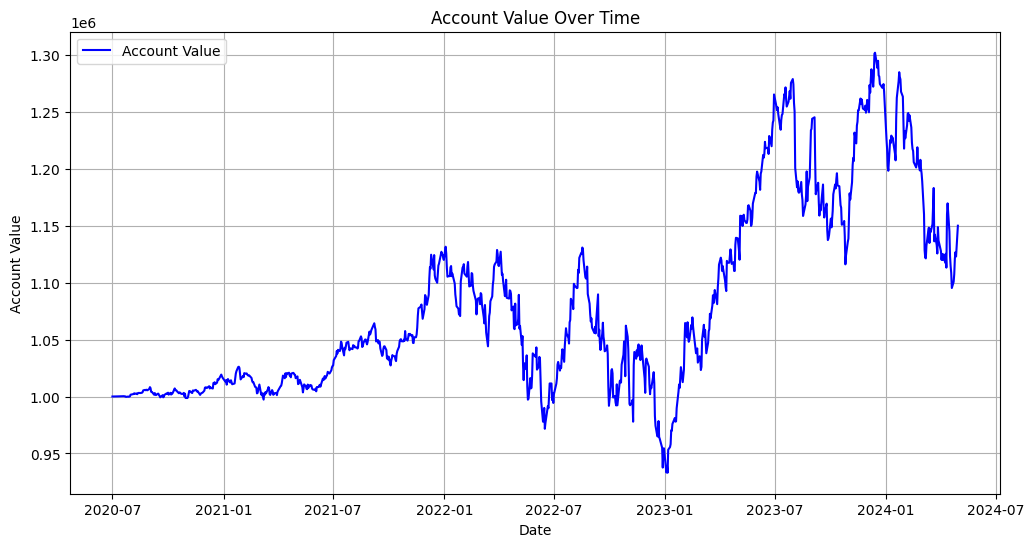

In [ ]:
import matplotlib.pyplot as plt

df_account_value_a2c['date'] = pd.to_datetime(df_account_value_a2c['date'])

plt.figure(figsize=(12, 6))
plt.plot(df_account_value_a2c['date'], df_account_value_a2c['account_value'], label='Account Value', color='b')

plt.xlabel('Date')
plt.ylabel('Account Value')
plt.title('Account Value Over Time')
plt.legend()
plt.grid(True)
plt.show()
